In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import(
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)



In [ ]:
df = pd.read_csv(r"../dataset/train.csv")

df.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [5]:
df = df.drop("id", axis=1)

x=df.drop("health_condition", axis=1)
y=df["health_condition"]

In [6]:
numerical_columns = x.select_dtypes(include=["int64", "float64"]).columns

for column in numerical_columns:
    x[column]=x[column].fillna(x[column].median()) 

In [7]:
categorical_columns = x.select_dtypes(include=["object"]).columns

for column in categorical_columns:
    x[column] = x[column].fillna(x[column].mode()[0])

C:\Users\udnrm\AppData\Local\Temp\ipykernel_2344\441477592.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = x.select_dtypes(include=["object"]).columns


In [21]:
x = pd.get_dummies(x, drop_first=True, dtype=int)

feature_names = x.columns.tolist()

x_train, x_valid, y_train, y_valid = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [22]:
print(x_train.shape)
print(x_valid.shape)

(552070, 19)
(138018, 19)


In [10]:
x_small, _, y_small, _ = train_test_split(
    x_train,
    y_train,
    train_size=100000,
    stratify=y_train,
    random_state=42
)

In [11]:
scaler = StandardScaler()

x_small_scaled = scaler.fit_transform(x_small)
x_valid_scaled = scaler.fit_transform(x_valid)

In [12]:
svc_model = SVC(
    kernel="rbf",
    C=100,
    gamma=0.01,
    random_state=42,
    class_weight="balanced",

)

In [13]:
start = time.time()

svc_model.fit(x_small_scaled, y_small)

end = time.time()

print("Training Time:", round(end-start,2),"seconds")

Training Time: 1151.39 seconds


In [14]:
y_pred = svc_model.predict(x_valid_scaled)

87.27484820820473
              precision    recall  f1-score   support

     at-risk       0.98      0.87      0.92    118512
         fit       0.51      0.90      0.65      7961
   unhealthy       0.55      0.84      0.66     11545

    accuracy                           0.87    138018
   macro avg       0.68      0.87      0.74    138018
weighted avg       0.91      0.87      0.88    138018

[[103625   6957   7930]
 [   721   7184     56]
 [  1865     34   9646]]


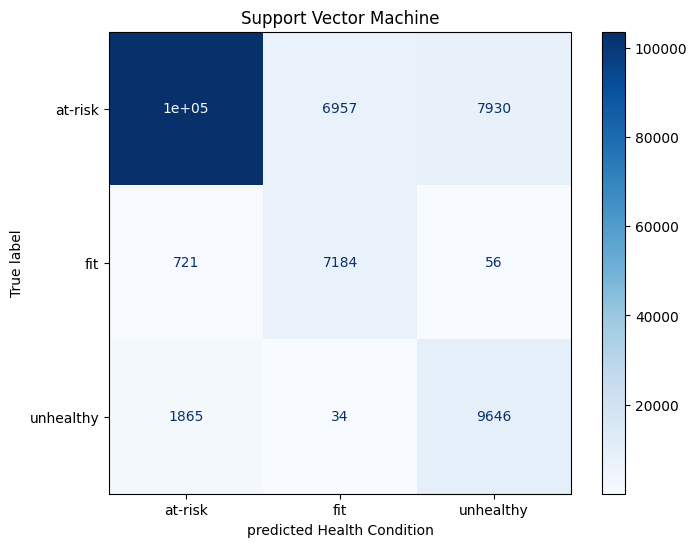

In [15]:
accuracy = accuracy_score(y_valid, y_pred)
print(accuracy*100
)

print(classification_report(y_valid, y_pred))

cm = confusion_matrix(y_valid, y_pred)
print(cm)


fig, ax = plt.subplots(figsize=(8,6))

ConfusionMatrixDisplay.from_predictions(
    y_valid,
    y_pred,
    display_labels=svc_model.classes_,
    cmap="Blues",
    ax=ax
)

plt.title("Support Vector Machine")
plt.xlabel("predicted Health Condition")
plt.show()

In [23]:
os.makedirs("models_svc", exist_ok=True)

joblib.dump(svc_model, "models_svc/svc_model.pkl")
joblib.dump(scaler, "models_svc/scaler.pkl")
joblib.dump(feature_names, "models_svc/feature_names.pkl")

print("SVC artifacts saved successfully!")


SVC artifacts saved successfully!


In [ ]:
test_df = pd.read_csv(r"../dataset/test.csv")

test_ids = test_df["id"]


test_df = test_df.drop("id", axis=1)

for column in numerical_columns:
    test_df[column] = test_df[column].fillna(
        test_df[column].median()
    )


for column in categorical_columns:
    test_df[column] = test_df[column].fillna(
        test_df[column].mode()[0]
    )

In [25]:
test_df = pd.get_dummies(
    test_df,
    drop_first=True,
    dtype=int
)

In [26]:
test_df = test_df.reindex(
    columns=feature_names,
    fill_value=0
)

In [27]:
test_scaled = scaler.transform(test_df)

In [28]:
predictions = svc_model.predict(test_scaled)

In [29]:
submission = pd.DataFrame({
    "id": test_ids,
    "health_condition": predictions
})

os.makedirs("Submissions", exist_ok=True)

submission.to_csv(
    "Submissions/svc_submission.csv",
    index=False
)

print("SVC submission created successfully!")
print(submission.head())
print(submission.shape)

SVC submission created successfully!
       id health_condition
0  690088        unhealthy
1  690089        unhealthy
2  690090          at-risk
3  690091          at-risk
4  690092        unhealthy
(295753, 2)
